<img src="../Pierian-Data-Logo.PNG">
<br>
<strong><center>Copyright 2019. Created by Jose Marcial Portilla.</center></strong>

# Neural Network Exercises
For these exercises we'll perform a binary classification on the Census Income dataset available from the <a href = 'http://archive.ics.uci.edu/ml/datasets/Adult'>UC Irvine Machine Learning Repository</a><br>
The goal is to determine if an individual earns more than $50K based on a set of continuous and categorical variables.

<div class="alert alert-danger" style="margin: 10px"><strong>IMPORTANT NOTE!</strong> Make sure you don't run the cells directly above the example output shown, <br>otherwise you will end up writing over the example output!</div>

## Census Income Dataset
For this exercises we're using the Census Income dataset available from the <a href='http://archive.ics.uci.edu/ml/datasets/Adult'>UC Irvine Machine Learning Repository</a>.

The full dataset has 48,842 entries. For this exercise we have reduced the number of records, fields and field entries, and have removed entries with null values. The file <strong>income.csv</strong> has	30,000 entries

Each entry contains the following information about an individual:
* <strong>age</strong>: the age of an individual as an integer from 18 to 90 (continuous)
* <strong>sex</strong>: Male or Female (categorical)
* <strong>education</strong>: represents the highest level of education achieved by an individual (categorical)
* <strong>education_num</strong>: represents education as an integer from 3 to 16 (categorical)
<div><table style="display: inline-block">
<tr><td>3</td><td>5th-6th</td><td>8</td><td>12th</td><td>13</td><td>Bachelors</td></tr>
<tr><td>4</td><td>7th-8th</td><td>9</td><td>HS-grad</td><td>14</td><td>Masters</td></tr>
<tr><td>5</td><td>9th</td><td>10</td><td>Some-college</td><td>15</td><td>Prof-school</td></tr>
<tr><td>6</td><td>10th</td><td>11</td><td>Assoc-voc</td><td>16</td><td>Doctorate</td></tr>
<tr><td>7</td><td>11th</td><td>12</td><td>Assoc-acdm</td></tr>
</table></div>
* <strong>marital-status</strong>: marital status of an individual (categorical)
<div><table style="display: inline-block">
<tr><td>Married</td><td>Divorced</td><td>Married-spouse-absent</td></tr>
<tr><td>Separated</td><td>Widowed</td><td>Never-married</td></tr>
</table></div>
* <strong>workclass</strong>: a general term to represent the employment status of an individual (categorical)
<div><table style="display: inline-block">
<tr><td>Local-gov</td><td>Private</td></tr>
<tr><td>State-gov</td><td>Self-emp</td></tr>
<tr><td>Federal-gov</td></tr>
</table></div>
* <strong>occupation</strong>: the general type of occupation of an individual (categorical)
<div><table style="display: inline-block">
<tr><td>Adm-clerical</td><td>Handlers-cleaners</td><td>Protective-serv</td></tr>
<tr><td>Craft-repair</td><td>Machine-op-inspct</td><td>Sales</td></tr>
<tr><td>Exec-managerial</td><td>Other-service</td><td>Tech-support</td></tr>
<tr><td>Farming-fishing</td><td>Prof-specialty</td><td>Transport-moving</td></tr>
</table></div>
* <strong>hours-per-week</strong>: the hours an individual has reported to work per week as an integer from 20 to 90 (continuous)
* <strong>income</strong>: whether or not an individual makes more than \\$50,000 annually (label)
* <strong>label</strong>: income represented as an integer (0: <=\\$50K, 1: >\\$50K) (optional label)

## Perform standard imports
Run the cell below to load the libraries needed for this exercise and the Census Income dataset.

In [123]:
import torch
import torch.nn as nn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.utils import shuffle

%config InlineBackened.format_figure = "svg"

df = pd.read_csv('../Data/income.csv')

In [124]:
print(len(df))
df.head()

30000


,age,sex,education,education-num,marital-status,workclass,occupation,hours-per-week,income,label
0,27,Male,HS-grad,9,Never-married,Private,Craft-repair,40,<=50K,0
1,47,Male,Masters,14,Married,Local-gov,Exec-managerial,50,>50K,1
2,59,Male,HS-grad,9,Divorced,Self-emp,Prof-specialty,20,<=50K,0
3,38,Female,Prof-school,15,Never-married,Federal-gov,Prof-specialty,57,>50K,1
4,64,Female,11th,7,Widowed,Private,Farming-fishing,40,<=50K,0


In [125]:
df['label'].value_counts()

label
0    21700
1     8300
Name: count, dtype: int64

### 1. Separate continuous, categorical and label column names
You should find that there are 5 categorical columns, 2 continuous columns and 1 label.<br>
In the case of <em>education</em> and <em>education-num</em> it doesn't matter which column you use. For the label column, be sure to use <em>label</em> and not <em>income</em>.<br>
Assign the variable names "cat_cols", "cont_cols" and "y_col" to the lists of names.

In [126]:
df.columns

Index(['age', 'sex', 'education', 'education-num', 'marital-status',
       'workclass', 'occupation', 'hours-per-week', 'income', 'label'],
      dtype='object')

In [127]:
df.info(memory_usage='deep' , show_counts='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             30000 non-null  int64 
 1   sex             30000 non-null  object
 2   education       30000 non-null  object
 3   education-num   30000 non-null  int64 
 4   marital-status  30000 non-null  object
 5   workclass       30000 non-null  object
 6   occupation      30000 non-null  object
 7   hours-per-week  30000 non-null  int64 
 8   income          30000 non-null  object
 9   label           30000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 12.1 MB


In [128]:
for col in df.columns:
    print(df[col].dtype)

int64
object
object
int64
object
object
object
int64
object
int64


In [129]:
df.select_dtypes('int64').columns , df.select_dtypes('object').columns

(Index(['age', 'education-num', 'hours-per-week', 'label'], dtype='object'),
 Index(['sex', 'education', 'marital-status', 'workclass', 'occupation',
        'income'],
       dtype='object'))

In [130]:
df.select_dtypes('int64').head(10)

,age,education-num,hours-per-week,label
0,27,9,40,0
1,47,14,50,1
2,59,9,20,0
3,38,15,57,1
4,64,7,40,0
5,53,14,40,1
6,23,9,40,0
7,52,9,40,0
8,31,9,40,0
9,22,9,40,0


In [131]:
df.select_dtypes('object').head(5)

,sex,education,marital-status,workclass,occupation,income
0,Male,HS-grad,Never-married,Private,Craft-repair,<=50K
1,Male,Masters,Married,Local-gov,Exec-managerial,>50K
2,Male,HS-grad,Divorced,Self-emp,Prof-specialty,<=50K
3,Female,Prof-school,Never-married,Federal-gov,Prof-specialty,>50K
4,Female,11th,Widowed,Private,Farming-fishing,<=50K


In [132]:
# CODE HERE
cat_cols = df.select_dtypes('object').columns.to_list()[:-1] # ['sex', 'education' , 'marital-status' , 'workclass' , 'occupation']
cont_cols = df.select_dtypes('int64').columns.to_list()[:-1] # ['age', 'education-num', 'hours-per-week']
y_col = [df.select_dtypes('int64').columns[-1]] # ['Label']


# RUN THIS CODE TO COMPARE RESULTS:
print(f'cat_cols  has {len(cat_cols)} columns.')
print(f'cont_cols has {len(cont_cols)} columns.')
print(f'y_col     has {len(y_col)} column.')

cat_cols  has 5 columns.
cont_cols has 3 columns.
y_col     has 1 column.


### 2. Convert categorical columns to category dtypes

In [133]:
# CODE HERE
for col in cat_cols:
    df[col] = df[col].astype('category')

In [134]:
df[cat_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   sex             30000 non-null  category
 1   education       30000 non-null  category
 2   marital-status  30000 non-null  category
 3   workclass       30000 non-null  category
 4   occupation      30000 non-null  category
dtypes: category(5)
memory usage: 148.2 KB


### Optional: Shuffle the dataset
The <strong>income.csv</strong> dataset is already shuffled. However, if you would like to try different configurations after completing the exercises, this is where you would want to shuffle the entire set.

In [135]:
# THIS CELL IS OPTIONAL
df = shuffle(df, random_state=101)
df.reset_index(drop=True, inplace=True)
df.head()

,age,sex,education,education-num,marital-status,workclass,occupation,hours-per-week,income,label
0,23,Female,HS-grad,9,Never-married,Private,Other-service,50,<=50K,0
1,37,Female,Prof-school,15,Married,State-gov,Prof-specialty,39,>50K,1
2,34,Male,Some-college,10,Divorced,Private,Adm-clerical,40,<=50K,0
3,31,Male,HS-grad,9,Married,Private,Craft-repair,40,>50K,1
4,20,Female,Some-college,10,Never-married,Private,Sales,25,<=50K,0


### 3. Set the embedding sizes
Create a variable "cat_szs" to hold the number of categories in each variable.<br>
Then create a variable "emb_szs" to hold the list of (category size, embedding size) tuples.

In [136]:
cat_sizes = [len(df[col].unique()) for col in cat_cols]
cat_sizes

[2, 14, 6, 5, 12]

In [137]:
emb_sizes = [(size , min(50, (size+1)//2)) for size in cat_sizes]
emb_sizes

[(2, 1), (14, 7), (6, 3), (5, 3), (12, 6)]

### 4. Create an array of categorical values
Create a NumPy array called "cats" that contains a stack of each categorical column <tt>.cat.codes.values</tt><br>
Note: your output may contain different values. Ours came after performing the shuffle step shown above.

In [138]:
df["sex"].cat.codes

0        0
1        0
2        1
3        1
4        0
        ..
29995    1
29996    0
29997    1
29998    0
29999    1
Length: 30000, dtype: int8

In [139]:
df["sex"].cat.codes.values

array([0, 0, 1, ..., 1, 0, 1], dtype=int8)

In [140]:
cats = np.stack([df[col].cat.codes for col in cat_cols] ,axis = 1)
cats

array([[ 0, 10,  3,  2,  6],
       [ 0, 12,  1,  4,  7],
       [ 1, 13,  0,  2,  0],
       ...,
       [ 1, 10,  1,  2,  2],
       [ 0,  6,  3,  2,  0],
       [ 1,  8,  5,  3,  9]], dtype=int8)

In [141]:
cats[:5]

array([[ 0, 10,  3,  2,  6],
       [ 0, 12,  1,  4,  7],
       [ 1, 13,  0,  2,  0],
       [ 1, 10,  1,  2,  1],
       [ 0, 13,  3,  2,  9]], dtype=int8)

### 5. Convert "cats" to a tensor
Convert the "cats" NumPy array to a tensor of dtype <tt>int64</tt>

In [142]:
# CODE HERE
cats = torch.tensor(cats , dtype = torch.int64)
cats

tensor([[ 0, 10,  3,  2,  6],
        [ 0, 12,  1,  4,  7],
        [ 1, 13,  0,  2,  0],
        ...,
        [ 1, 10,  1,  2,  2],
        [ 0,  6,  3,  2,  0],
        [ 1,  8,  5,  3,  9]])

In [ ]:
cats.dtype , type(cats)

### 6. Create an array of continuous values
Create a NumPy array called "conts" that contains a stack of each continuous column.<br>
Note: your output may contain different values. Ours came after performing the shuffle step shown above.

In [143]:
cont_cols

['age', 'education-num', 'hours-per-week']

In [144]:
np.stack([df[col] for col in cont_cols] , axis = 1)

array([[23,  9, 50],
       [37, 15, 39],
       [34, 10, 40],
       ...,
       [62,  9, 45],
       [37, 12, 40],
       [50, 13, 65]], dtype=int64)

In [145]:
# CODE HERE
conts = np.stack([df[col] for col in cont_cols] , axis = 1)

# RUN THIS CODE TO COMPARE RESULTS
conts[:5]

array([[23,  9, 50],
       [37, 15, 39],
       [34, 10, 40],
       [31,  9, 40],
       [20, 10, 25]], dtype=int64)

### 7. Convert "conts" to a tensor
Convert the "conts" NumPy array to a tensor of dtype <tt>float32</tt>

In [146]:
# CODE HERE
conts = torch.tensor(conts , dtype=torch.float)

# RUN THIS CODE TO COMPARE RESULTS
conts.dtype

torch.float32

### 8. Create a label tensor
Create a tensor called "y" from the values in the label column. Be sure to flatten the tensor so that it can be passed into the CE Loss function.

In [147]:
y_col

['label']

In [148]:
df[y_col]

,label
0,0
1,1
2,0
3,1
4,0
...,...
29995,0
29996,0
29997,1
29998,0


In [149]:
# CODE HERE
y = torch.tensor(df[y_col].values , dtype=torch.int64)
y

tensor([[0],
        [1],
        [0],
        ...,
        [1],
        [0],
        [1]])

In [150]:
y.flatten()

tensor([0, 1, 0,  ..., 1, 0, 1])

In [151]:
y = y.flatten()
y

tensor([0, 1, 0,  ..., 1, 0, 1])

### 9. Create train and test sets from <tt>cats</tt>, <tt>conts</tt>, and <tt>y</tt>
We use the entire batch of 30,000 records, but a smaller batch size will save time during training.<br>
We used a test size of 5,000 records, but you can choose another fixed value or a percentage of the batch size.<br>
Make sure that your test records remain separate from your training records, without overlap.<br>
To make coding slices easier, we recommend assigning batch and test sizes to simple variables like "b" and "t".

In [152]:
# CODE HERE
batch_size = 30000 # suggested batch size
test_size = 5000  # suggested test size
# batch_size - test_size = 25000

cat_train = cats[:batch_size - test_size]
cat_test = cats[batch_size - test_size : batch_size]

con_train = conts[:batch_size - test_size]
con_test = conts[batch_size - test_size:batch_size]

y_train = y[:batch_size - test_size]
y_test = y[batch_size - test_size:batch_size]

### Define the model class
Run the cell below to define the TabularModel model class we've used before.

In [153]:
class TabularModel(nn.Module):

    def __init__(self, emb_szs, n_cont, out_sz, layers, p=0.5):
        # Call the parent __init__
        super().__init__()
        
        # Set up the embedding, dropout, and batch normalization layer attributes
        self.embeds = nn.ModuleList([nn.Embedding(num_embeddings=ni, embedding_dim=nf) for ni,nf in emb_szs]) #Embedding layers for categorical features
        self.emb_drop = nn.Dropout(p) #Dropout for embeddings
        self.bn_cont = nn.BatchNorm1d(n_cont) #BatchNorm for continuous variables
        
        # Assign a variable to hold a list of layers
        layerlist = []
        
        # Assign a variable to store the number of embedding and continuous layers
        n_emb = sum((nf for ni,nf in emb_szs))
        n_in = n_emb + n_cont
        
        # Iterate through the passed-in "layers" parameter (ie, [200,100]) to build a list of layers
        for i in layers:
            layerlist.append(nn.Linear(n_in,i)) 
            layerlist.append(nn.ReLU(inplace=True))
            layerlist.append(nn.BatchNorm1d(i))
            layerlist.append(nn.Dropout(p))
            n_in = i
        layerlist.append(nn.Linear(layers[-1],out_sz))
        
        # Convert the list of layers into an attribute
        self.layers = nn.Sequential(*layerlist)
    
    def forward(self, x_cat, x_cont):
        # Extract embedding values from the incoming categorical data
        embeddings = []
        for i,e in enumerate(self.embeds):
            embeddings.append(e(x_cat[:,i]))
        x = torch.cat(embeddings, 1)
        # Perform an initial dropout on the embeddings
        x = self.emb_drop(x)
        
        # Normalize the incoming continuous data
        x_cont = self.bn_cont(x_cont)
        x = torch.cat([x, x_cont], 1)
        
        # Set up model layers
        x = self.layers(x)
        return x

### 10. Set the random seed
To obtain results that can be recreated, set a torch manual_seed (we used 33).

In [154]:
# CODE HERE
torch.manual_seed(seed = 33)

### 11. Create a TabularModel instance
Create an instance called "model" with one hidden layer containing 50 neurons and a dropout layer p-value of 0.4

In [155]:
# CODE HERE
model = TabularModel(emb_szs = emb_sizes, 
                     n_cont=conts.shape[1] ,
                     out_sz=2 ,
                     layers=[50] , 
                     p=0.4)
# RUN THIS CODE TO COMPARE RESULTS
model

TabularModel(
  (embeds): ModuleList(
    (0): Embedding(2, 1)
    (1): Embedding(14, 7)
    (2): Embedding(6, 3)
    (3): Embedding(5, 3)
    (4): Embedding(12, 6)
  )
  (emb_drop): Dropout(p=0.4, inplace=False)
  (bn_cont): BatchNorm1d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layers): Sequential(
    (0): Linear(in_features=23, out_features=50, bias=True)
    (1): ReLU(inplace=True)
    (2): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=50, out_features=2, bias=True)
  )
)

In [156]:
model.parameters

<bound method Module.parameters of TabularModel(
  (embeds): ModuleList(
    (0): Embedding(2, 1)
    (1): Embedding(14, 7)
    (2): Embedding(6, 3)
    (3): Embedding(5, 3)
    (4): Embedding(12, 6)
  )
  (emb_drop): Dropout(p=0.4, inplace=False)
  (bn_cont): BatchNorm1d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layers): Sequential(
    (0): Linear(in_features=23, out_features=50, bias=True)
    (1): ReLU(inplace=True)
    (2): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=50, out_features=2, bias=True)
  )
)>

### 12. Define the loss and optimization functions
Create a loss function called "criterion" using CrossEntropyLoss<br>
Create an optimization function called "optimizer" using Adam, with a learning rate of 0.001

In [157]:
# CODE HERE
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model.parameters() , lr = 0.001)

### Train the model
Run the cell below to train the model through 300 epochs. Remember, results may vary!<br>
After completing the exercises, feel free to come back to this section and experiment with different parameters.

In [158]:
y_train = y_train.long()

In [159]:
import time
start_time =  time.time()

epochs = 300
losses = []

for i in range(epochs):
    i+=1
    y_pred = model(cat_train , con_train)
    loss = criterion(y_pred , y_train)
    losses.append(loss)


    # a neat trick to save screen space:
    if i%25 == 1:
        print(f"epoch: {i:3}   loss: {loss.item():10.8f}")

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


print(f"epoch: {i:3}  loss:{loss.item():10.8f}") # print the last line
print(f"\nDuration {time.time() - start_time:.0f}second") # print the time elapsed


epoch:   1   loss: 0.89122540
epoch:  26   loss: 0.60635370
epoch:  51   loss: 0.51551986
epoch:  76   loss: 0.46236739
epoch: 101   loss: 0.42993867
epoch: 126   loss: 0.40243649
epoch: 151   loss: 0.37636161
epoch: 176   loss: 0.36376292
epoch: 201   loss: 0.34738171
epoch: 226   loss: 0.33574668
epoch: 251   loss: 0.32852378
epoch: 276   loss: 0.31925079
epoch: 300  loss:0.31373945

Duration 10second


### 13. Plot the Cross Entropy Loss against epochs
Results may vary. The shape of the plot is what matters.

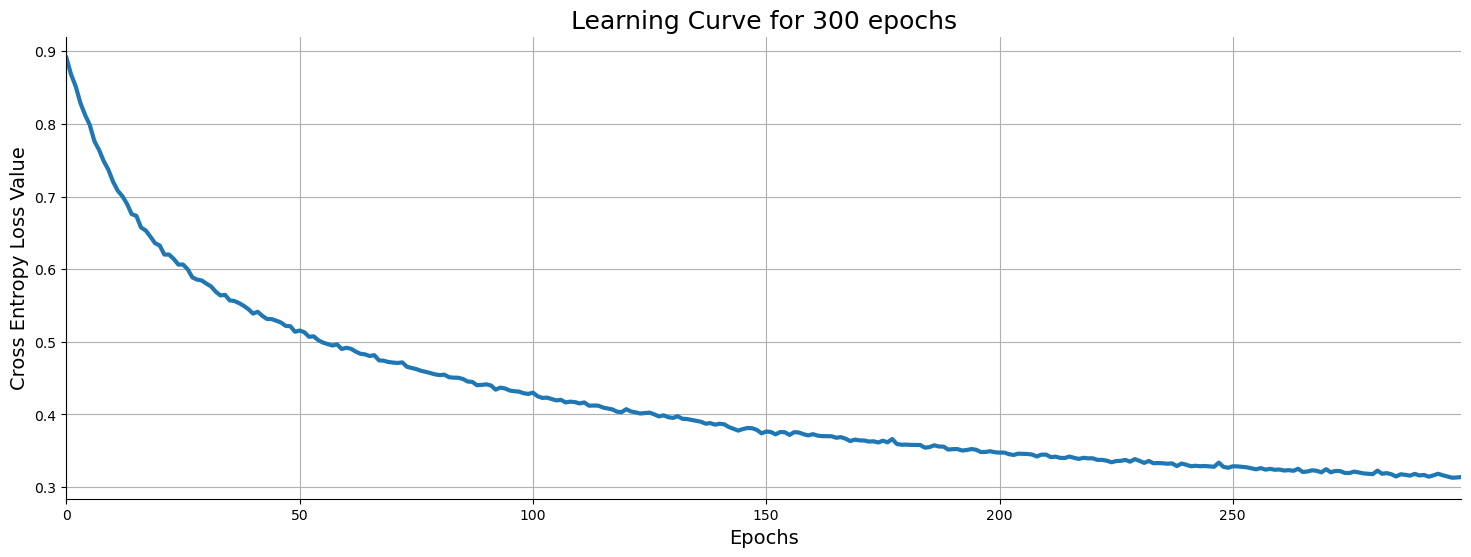

In [160]:
# CODE HERE
plt.figure(figsize = (18,6))
plt.plot(np.arange(epochs) , [loss.detach().numpy() for loss in losses] , lw = 3 , ls = "-")

plt.title(f"Learning Curve for {epochs} epochs" , fontsize = 18)
plt.xlabel("Epochs" , fontsize = 14)
plt.ylabel("Cross Entropy Loss Value", fontsize = 14)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.autoscale(enable=True ,  axis="x" , tight = True)
plt.grid()
plt.show()


### 14. Evaluate the test set
With torch set to <tt>no_grad</tt>, pass <tt>cat_test</tt> and <tt>con_test</tt> through the trained model. Create a validation set called "y_val". Compare the output to <tt>y_test</tt> using the loss function defined above. Results may vary.

In [161]:
# CODE HERE
with torch.no_grad():
    y_val = model(cat_test , con_test)
    loss = criterion(y_val , y_test)

# RUN THIS CODE TO COMPARE RESULTS
print(f'CE Loss: {loss:.8f}')

CE Loss: 0.33403578


### 15. Calculate the overall percent accuracy
Using a for loop, compare the argmax values of the <tt>y_val</tt> validation set to the <tt>y_test</tt> set.

In [162]:
# CODE HERE
rows = len(y_test)
correct = 0

# print(f'{"MODEL OUTPUT":26} ARGMAX  Y_TEST')

for i in range(rows):
    # print(f'{str(y_val[i]):26} {y_val[i].argmax().item():^7}{y_test[i]:^7}')

    if y_val[i].argmax().item() == y_test[i]:
        correct += 1

print(f'\n{correct} out of {rows} = {100*correct/rows:.2f}% correct')


4215 out of 5000 = 84.30% correct


### BONUS: Feed new data through the trained model
See if you can write a function that allows a user to input their own values, and generates a prediction.<br>
<strong>HINT</strong>:<br>There's no need to build a DataFrame. You can use inputs to populate column variables, convert them to embeddings with a context dictionary, and pass the embedded values directly into the tensor constructors:<br>
<pre>mar = input("What is the person's marital status? ")
mar_d = dict(Divorced=0, Married=1, Married-spouse-absent=2, Never-married=3, Separated=4, Widowed=5)
mar = mar_d[mar]
cats = torch.tensor([..., ..., mar, ..., ...], dtype=torch.int64).reshape(1,-1)</pre>
Make sure that names are put in alphabetical order before assigning numbers.

Also, be sure to run <tt>model.eval()</tt> before passing new date through. Good luck!

In [163]:
def test_data(mdl):
    age = float(input("What is the person's age? (18-90)  ").strip())
    sex = input("What is the person's sex? (e.g. Male/Female) ").strip().lower()
    education = input("What is the person's education? (e.g. HS-grad, Bachelors) ").strip().lower()
    edn = int(input("What is the person's education-num? (3-16) ").strip())
    mar = input("What is the person's marital status? ").strip().lower()
    wrk = input("What is the person's workclass? ").strip().lower()
    occ = input("What is the person's occupation? ").strip().lower()
    hrs = float(input("How many hours/week are worked? (20-90)  ").strip())

    # build lower-cased mapping dicts from dataframe categories
    sex_d = {k.lower():v for v,k in enumerate(df['sex'].cat.categories)}
    edu_d = {k.lower():v for v,k in enumerate(df['education'].cat.categories)}
    mar_d = {k.lower():v for v,k in enumerate(df['marital-status'].cat.categories)}
    wrk_d = {k.lower():v for v,k in enumerate(df['workclass'].cat.categories)}
    occ_d = {k.lower():v for v,k in enumerate(df['occupation'].cat.categories)}

    try:
        sex_c = sex_d[sex]
        edu_c = edu_d[education]
        mar_c = mar_d[mar]
        wrk_c = wrk_d[wrk]
        occ_c = occ_d[occ]
    except KeyError as e:
        raise ValueError(f"Invalid category input: {e}. Please match dataset category names.") from e

    # categorical order: ['sex','education','marital-status','workclass','occupation']
    cats = torch.tensor([sex_c, edu_c, mar_c, wrk_c, occ_c], dtype=torch.int64).reshape(1, -1)
    # continuous order: ['age','education-num','hours-per-week']
    conts = torch.tensor([age, edn, hrs], dtype=torch.float).reshape(1, -1)

    mdl.eval()
    with torch.no_grad():
        z = mdl(cats, conts).argmax().item()

    print(f'\nThe predicted label is {z}')

test_data(model)


The predicted label is 1


## Great job!